# 03 · Model Training — ECGResNet 3-class

Trains a lightweight 1D ResNet on the preprocessed ECG data.

- Balanced sampling (10K per class) + data augmentation on minority classes
- Per-beat normalization (zero mean, unit variance)
- Early stopping based on Macro F1 on unseen patients (patience=20)
- Best checkpoint saved as `ecg_resnet_best.pth`

Trained on: NVIDIA RTX 5070 · CUDA · Python 3.11

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Seed fija para reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

X_train     = np.load('X_train_pi.npy')
X_test      = np.load('X_test_pi.npy')
y_train_raw = np.load('y_train_pi.npy')
y_test_raw  = np.load('y_test_pi.npy')

le_old = LabelEncoder()
le_old.fit(['A', 'N', 'R', 'V'])
y_train_letters = le_old.inverse_transform(y_train_raw)
y_test_letters  = le_old.inverse_transform(y_test_raw)

VALID      = {'N', 'V', 'R'}
mask_train = np.array([l in VALID for l in y_train_letters])
mask_test  = np.array([l in VALID for l in y_test_letters])

X_train = X_train[mask_train]; X_test = X_test[mask_test]
y_train = y_train_letters[mask_train]
y_test  = y_test_letters[mask_test]

le = LabelEncoder()
le.fit(['N', 'R', 'V'])
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print(f'Train shape : {X_train.shape}')
print(f'Test  shape : {X_test.shape}')
print(f'Classes     : {list(le.classes_)}')
print(f'\n-- Train distribution --')
for cls, count in sorted(Counter(y_train).items()):
    print(f'  {cls} -> {count:>6} ({100*count/len(y_train):.1f}%)')
print(f'\n-- Test distribution --')
for cls, count in sorted(Counter(y_test).items()):
    print(f'  {cls} -> {count:>6} ({100*count/len(y_test):.1f}%)')


Train shape : (204750, 2, 500)
Test  shape : (58531, 2, 500)
Classes     : [np.str_('N'), np.str_('R'), np.str_('V')]

-- Train distribution --
  N -> 176865 (86.4%)
  R ->   9079 (4.4%)
  V ->  18806 (9.2%)

-- Test distribution --
  N ->  48759 (83.3%)
  R ->   1345 (2.3%)
  V ->   8427 (14.4%)


In [4]:
# Balancing
TARGET = 10000
rng    = np.random.default_rng(SEED)

X_bal, y_bal = [], []
for cls in ['N', 'R', 'V']:
    idx = np.where(y_train == cls)[0]
    if len(idx) > TARGET:
        idx = rng.choice(idx, TARGET, replace=False)
    X_bal.append(X_train[idx])
    y_bal.append(np.array([cls] * len(idx)))
    print(f'  {cls} -> {len(idx)} samples')

X_bal     = np.concatenate(X_bal).astype(np.float32)
y_bal     = np.concatenate(y_bal)
y_bal_enc = le.transform(y_bal)
print(f'Balanced shape: {X_bal.shape}')


  N -> 10000 samples
  R -> 9079 samples
  V -> 10000 samples
Balanced shape: (29079, 2, 500)


In [5]:
# Normalization
def normalize_beats(X):
    mu  = X.mean(axis=-1, keepdims=True)
    std = X.std(axis=-1,  keepdims=True) + 1e-8
    return (X - mu) / std

X_bal      = normalize_beats(X_bal)
X_test     = normalize_beats(X_test.astype(np.float32))
y_test_enc = le.transform(y_test)
print('Normalization done.')


Normalization done.


In [6]:
# Dataset con augmentation
class ECGDataset(Dataset):
    def __init__(self, X, y, augment=False, minority_classes=None, aug_target=TARGET):
        self.minority_classes = minority_classes or []
        self.aug_target       = aug_target
        if augment and minority_classes:
            X, y = self._balance(X, y)
        self.X = X
        self.y = y

    def _augment(self, x):
        x = x.copy()
        x += np.random.normal(0, 0.02, x.shape).astype(np.float32)
        x *= np.random.uniform(0.9, 1.1)
        x  = np.roll(x, np.random.randint(-15, 15), axis=-1)
        t  = np.linspace(0, 2 * np.pi, x.shape[-1])
        x += (np.random.uniform(0, 0.05) * np.sin(
              t + np.random.uniform(0, np.pi))).astype(np.float32)
        return x

    def _balance(self, X, y):
        X_out, y_out = list(X), list(y)
        counts = Counter(y.tolist())
        for cls_idx in self.minority_classes:
            cls_X  = X[y == cls_idx]
            needed = self.aug_target - counts[cls_idx]
            if needed <= 0: continue
            for i in range(needed):
                X_out.append(self._augment(cls_X[i % len(cls_X)]))
                y_out.append(cls_idx)
        return np.array(X_out, dtype=np.float32), np.array(y_out)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        return (torch.tensor(self.X[idx]),
                torch.tensor(self.y[idx], dtype=torch.long))

counts_bal   = Counter(y_bal_enc.tolist())
minority_cls = [i for i in range(len(le.classes_)) if counts_bal[i] < TARGET]

train_dataset = ECGDataset(X_bal, y_bal_enc, augment=True, minority_classes=minority_cls)
test_dataset  = ECGDataset(X_test, y_test_enc, augment=False)

aug_counts = Counter(train_dataset.y.tolist())
print('-- Augmented Train Distribution --')
for i, count in sorted(aug_counts.items()):
    print(f'  {le.classes_[i]} -> {count} ({100*count/len(train_dataset):.1f}%)')

g = torch.Generator(); g.manual_seed(SEED)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True,
                          num_workers=0, generator=g)
test_loader  = DataLoader(test_dataset,  batch_size=512, shuffle=False, num_workers=0)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')


-- Augmented Train Distribution --
  N -> 10000 (33.3%)
  R -> 10000 (33.3%)
  V -> 10000 (33.3%)
Train batches: 59 | Test batches: 115


In [7]:
# Model architecture — ECGResNet
class ResBlock(nn.Module):
    def __init__(self, channels, kernel_size=7):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size//2),
            nn.BatchNorm1d(channels), nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size//2),
            nn.BatchNorm1d(channels)
        )
        self.relu = nn.ReLU()
    def forward(self, x): return self.relu(x + self.conv(x))

class ECGResNet(nn.Module):
    def __init__(self, num_classes=3, in_channels=2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=15, padding=7),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2)
        )
        self.blocks = nn.Sequential(
            ResBlock(64), nn.MaxPool1d(2),
            ResBlock(64), nn.MaxPool1d(2),
            ResBlock(64)
        )
        self.pool       = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(64, 128),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.pool(self.blocks(self.stem(x))))
    def forward_features(self, x):
        return self.blocks(self.stem(x))

class FocalLoss(nn.Module):
    def __init__(self, gamma=1.5, smoothing=0.1, weight=None):
        super().__init__()
        self.gamma     = gamma
        self.smoothing = smoothing
        self.weight    = weight
    def forward(self, logits, targets):
        n = logits.size(1)
        with torch.no_grad():
            st = torch.full_like(logits, self.smoothing / (n - 1))
            st.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        lp    = torch.nn.functional.log_softmax(logits, dim=1)
        ce    = -(st * lp).sum(dim=1)
        pt    = lp.exp().gather(1, targets.unsqueeze(1)).squeeze(1)
        focal = ((1 - pt) ** self.gamma) * ce
        if self.weight is not None:
            focal = focal * self.weight[targets]
        return focal.mean()

device        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
class_counts  = np.array([aug_counts[i] for i in range(len(le.classes_))], dtype=np.float32)
class_weights = torch.tensor(1.0 / class_counts).to(device)
class_weights = class_weights / class_weights.sum() * len(le.classes_)

model     = ECGResNet(num_classes=3, in_channels=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6
)
criterion = FocalLoss(gamma=1.5, weight=class_weights)

print(f'Model   : ECGResNet 3-class (N, R, V)')
print(f'Params  : {sum(p.numel() for p in model.parameters()):,}')
print(f'Device  : {device}')
print(f'Config  : LR=1e-4, Dropout=0.5, Batch=512, FocalLoss gamma=1.5')
print(f'Seed    : {SEED}')
print(f'Note    : Best checkpoint reached Macro F1=0.860 on unseen patients')


Model   : ECGResNet 3-class (N, R, V)
Params  : 184,003
Device  : cuda
Config  : LR=1e-4, Dropout=0.5, Batch=512, FocalLoss gamma=1.5
Seed    : 42
Note    : Best checkpoint reached Macro F1=0.860 on unseen patients


In [6]:
# Training
def evaluate(model, loader, device):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds = model(xb.to(device)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(yb.numpy())
    return np.array(all_preds), np.array(all_true)

EPOCHS    = 60
PATIENCE  = 20
history   = {'train_loss': [], 'acc': [], 'macro_f1': []}
best_f1   = 0
best_epoch = 0
no_imp    = 0

print(f"{'Epoch':>6} {'Loss':>10} {'Acc':>9} {'MacroF1':>9} {'LR':>10}")
print('-' * 52)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()

    avg_loss    = total_loss / len(train_loader)
    preds, true = evaluate(model, test_loader, device)
    acc         = (preds == true).mean()
    macro_f1    = f1_score(true, preds, average='macro')
    cur_lr      = optimizer.param_groups[0]['lr']

    history['train_loss'].append(avg_loss)
    history['acc'].append(acc)
    history['macro_f1'].append(macro_f1)

    scheduler.step(macro_f1)

    if macro_f1 > best_f1:
        best_f1, best_epoch, no_imp = macro_f1, epoch, 0
        torch.save(model.state_dict(), 'ecg_resnet_best.pth')
        import shutil, time
        ts = time.strftime('%Y%m%d_%H%M%S')
        shutil.copy('ecg_resnet_best.pth', f'ecg_resnet_backup_{ts}_f1{macro_f1:.4f}.pth')
        tag = ' <- best'
    else:
        no_imp += 1
        tag = ''

    print(f'{epoch:>6} {avg_loss:>10.4f} {acc*100:>8.2f}% {macro_f1:>9.4f} {cur_lr:>10.2e}{tag}')
    if no_imp >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

print(f'\nBest model: epoch {best_epoch} - Macro F1: {best_f1:.4f}')
model.load_state_dict(torch.load('ecg_resnet_best.pth', weights_only=True))
print('Best model loaded.')


 Epoch       Loss       Acc   MacroF1         LR
----------------------------------------------------
     1     0.3411    68.85%    0.5592   1.00e-04 <- best
     2     0.1222    79.44%    0.7447   1.00e-04 <- best
     3     0.0791    82.97%    0.6849   1.00e-04
     4     0.0570    76.40%    0.6661   1.00e-04
     5     0.0447    84.70%    0.8043   1.00e-04 <- best
     6     0.0376    83.97%    0.7985   1.00e-04
     7     0.0313    81.62%    0.7846   1.00e-04
     8     0.0274    80.82%    0.6617   1.00e-04
     9     0.0239    89.69%    0.7296   1.00e-04
    10     0.0224    69.24%    0.6865   1.00e-04
    11     0.0183    85.31%    0.7316   1.00e-04
    12     0.0148    92.64%    0.8602   5.00e-05 <- best
    13     0.0128    91.49%    0.8110   5.00e-05
    14     0.0118    77.75%    0.7539   5.00e-05
    15     0.0108    87.70%    0.7573   5.00e-05
    16     0.0095    84.27%    0.7050   5.00e-05
    17     0.0087    74.50%    0.6971   5.00e-05
    18     0.0085    68.66%    0.

-- Classification Report (unseen patients) --
              precision    recall  f1-score   support

           N       0.97      0.94      0.96     48759
           R       0.76      0.94      0.84      1345
           V       0.73      0.85      0.79      8427

    accuracy                           0.93     58531
   macro avg       0.82      0.91      0.86     58531
weighted avg       0.93      0.93      0.93     58531

-- Per-class F1 --
  N -> 0.9558 OK
  R -> 0.8390 REVIEW
  V -> 0.7858 REVIEW
  Macro F1 : 0.8602


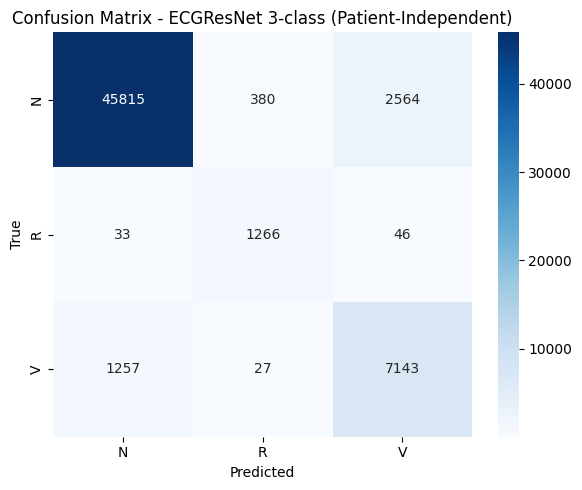

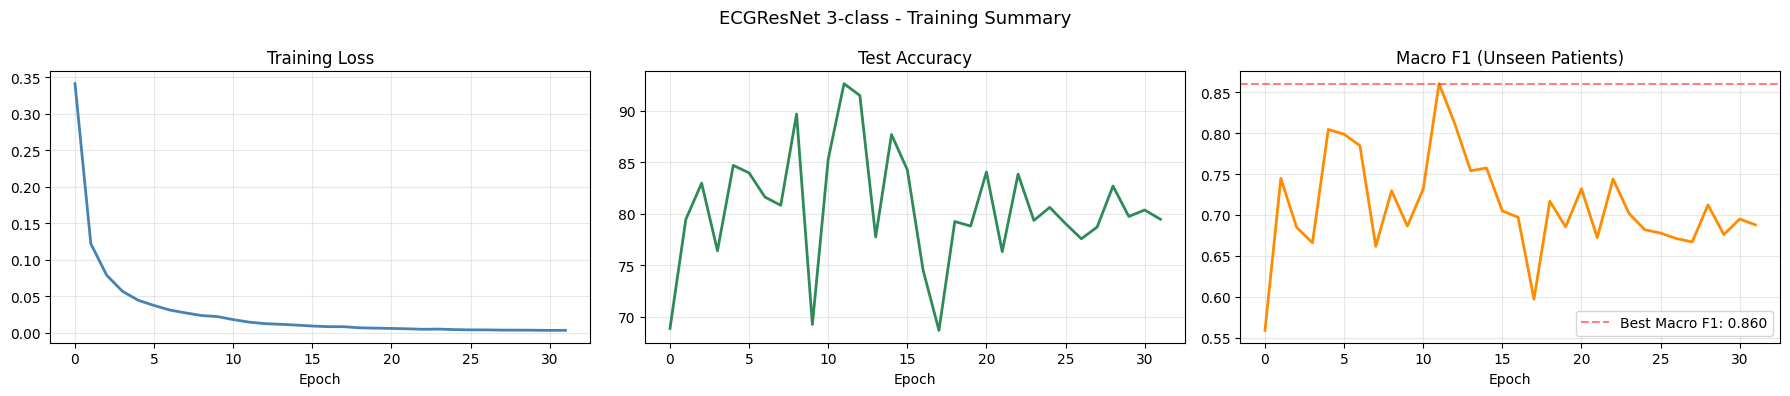

In [7]:
# Evaluation
class_names = list(le.classes_)
preds, true = evaluate(model, test_loader, device)

print('-- Classification Report (unseen patients) --')
print(classification_report(true, preds, target_names=class_names))

per_cls = f1_score(true, preds, average=None)
print('-- Per-class F1 --')
for cls, score in zip(class_names, per_cls):
    flag = 'OK' if score >= 0.85 else 'REVIEW'
    print(f'  {cls} -> {score:.4f} {flag}')
print(f'  Macro F1 : {per_cls.mean():.4f}')

cm = confusion_matrix(true, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Confusion Matrix - ECGResNet 3-class (Patient-Independent)')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150)
plt.show()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))
ax1.plot(history['train_loss'], color='steelblue', linewidth=2)
ax1.set_title('Training Loss'); ax1.set_xlabel('Epoch'); ax1.grid(alpha=0.3)
ax2.plot([a*100 for a in history['acc']], color='seagreen', linewidth=2)
ax2.set_title('Test Accuracy'); ax2.set_xlabel('Epoch'); ax2.grid(alpha=0.3)
ax3.plot(history['macro_f1'], color='darkorange', linewidth=2)
ax3.axhline(y=best_f1, color='red', linestyle='--', alpha=0.5,
            label=f'Best Macro F1: {best_f1:.3f}')
ax3.set_title('Macro F1 (Unseen Patients)')
ax3.set_xlabel('Epoch'); ax3.legend(); ax3.grid(alpha=0.3)
plt.suptitle('ECGResNet 3-class - Training Summary', fontsize=13)
plt.tight_layout()
plt.savefig('training_history_final.png', dpi=150)
plt.show()
